In [2]:
# Tissue Spatial Geometrics Lab | David H. Nguyen, PhD

# DBSCAN on 3D CSV Data + k-distance Plot
# Since this script is meant to do DBSCAN on the first 3 PC values of PCA analysis, the input data is already standardized 
#    before PCA was done. Thus, this script does not do any standardization, so the meaning of the PCA distance is maintained.

# Instructions
# 1. Paste in the file path directly to the csv file. Do this in the section called "USER INPUT:"
# 2. Run Steps 1-3 first. 
# 2. After analyzing the K-distance plot in Step 3, adjust the epsilon values (object named "eps") in Step 4. 
# 3. Then run Steps 4 and 5.
# 4. Step 4 also saves a CSV file with suffix "_DBSCAN-clusters.csv". It contains new columns named "Cluster" and "Cluster_Name".
# 5. Step 5 builds an interactive 3D Plotly plot. Hovering over a point shows its
#    cluster name, sample name, PC1, PC2, and PC3 values.

In [17]:
# Load the dependencies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

Data shape: (121, 3)
Using columns: ['PC1', 'PC2', 'PC3']
Sample name column: Sample_Name


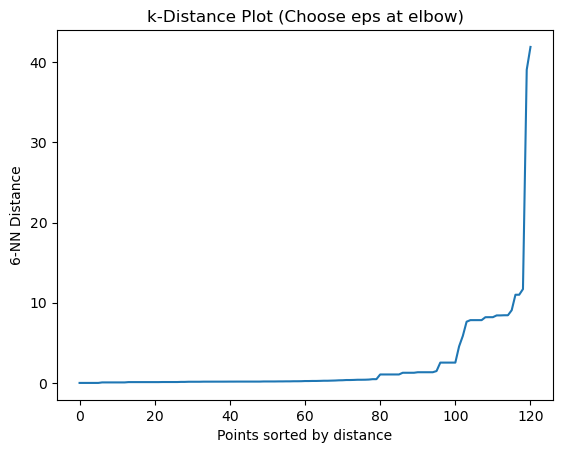

In [18]:
# ============================================================
# USER INPUT: Paste path to CSV file
# ============================================================

file_path = 'FilePath2CSVFile'

# Optional: name of the column in your CSV that identifies each sample/row
# (e.g. "Sample", "Sample Name", "ID"). Leave as None to auto-detect one,
# or set it explicitly, e.g. sample_name_column = "Sample Name"
sample_name_column = None

# ============================================================
# 1. Load CSV file
# ============================================================

df = pd.read_csv(file_path)

required_columns = ["PC1", "PC2", "PC3"]

# Check that required columns exist
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in CSV file.")

# Extract data in correct order
data = df[required_columns].values

# Auto-detect a sample-name column if one wasn't specified
if sample_name_column is None:
    candidates = [c for c in df.columns if c not in required_columns and
                  any(key in c.lower() for key in ["sample", "name", "id", "label"])]
    sample_name_column = candidates[0] if candidates else None

if sample_name_column is not None and sample_name_column in df.columns:
    sample_names = df[sample_name_column].astype(str).values
else:
    sample_names = np.array([f"Row {i}" for i in range(len(df))])
    print("No sample-name column found/specified; using row numbers as sample names.")

print("Data shape:", data.shape)
print("Using columns:", required_columns)
print("Sample name column:", sample_name_column)

# ============================================================
# 2. Compute k-distance plot
# ============================================================

min_samples = 6  # The conservative Rule of thumb for 3D is "2 x dimensions", but for smaller data sets its "dimenions+1", which is 4 for 3D data.

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(data)
distances, indices = neighbors_fit.kneighbors(data)

# Distance to kth nearest neighbor
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure()
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN Distance")
plt.title("k-Distance Plot (Choose eps at elbow)")
plt.show()

In [19]:
# ============================================================
# 4. Run DBSCAN (Adjust eps after viewing k-distance plot)
# ============================================================

eps = 8  # <-- Adjust after inspecting k-distance plot

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(data)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Estimated number of clusters:", n_clusters)
print("Estimated number of noise points:", n_noise)

# ============================================================
# 4b. Add cluster assignments to the data and save to CSV
# ============================================================

df["Cluster"] = labels
df["Cluster_Name"] = ["Noise" if lbl == -1 else f"Cluster {lbl}" for lbl in labels]

# Sort a copy by "Cluster" (ascending) for the saved CSV, without disturbing the
# row order of df/labels used later for the Step 5 interactive plot
df_sorted = df.sort_values("Cluster", ascending=True)

output_path = os.path.splitext(file_path)[0] + "_DBSCAN-clusters.csv"
df_sorted.to_csv(output_path, index=False)

print(f"Saved clustered data with cluster labels to: {output_path}")

Estimated number of clusters: 3
Estimated number of noise points: 15
Saved clustered data with cluster labels to: /Users/davidnguyen/Documents/demo2/Practice Files_DBSCAN/PracticeFile_for_DBSCAN_NormalvsBreastCancer_DBSCAN-clusters.csv


In [20]:
# ============================================================
# 5. Interactive 3D plot of clustering result (Plotly, opens in web browser)
# ============================================================

plot_df = df.copy()
plot_df["Sample_Name"] = sample_names

fig = go.Figure()

for label in sorted(set(labels)):
    mask = (labels == label)
    subset = plot_df[mask]
    cluster_name = "Noise" if label == -1 else f"Cluster {label}"

    fig.add_trace(go.Scatter3d(
        x=subset["PC1"],
        y=subset["PC2"],
        z=subset["PC3"],
        mode="markers",
        name=cluster_name,
        marker=dict(
            size=4,
            symbol="x" if label == -1 else "circle",
        ),
        customdata=np.stack([
            np.full(len(subset), cluster_name),
            subset["Sample_Name"].values,
            subset["PC1"].values,
            subset["PC2"].values,
            subset["PC3"].values,
        ], axis=-1),
        hovertemplate=(
            "<b>Cluster:</b> %{customdata[0]}<br>"
            "<b>Sample:</b> %{customdata[1]}<br>"
            "<b>PC1:</b> %{customdata[2]:.4f}<br>"
            "<b>PC2:</b> %{customdata[3]:.4f}<br>"
            "<b>PC3:</b> %{customdata[4]:.4f}<extra></extra>"
        ),
    ))

fig.update_layout(
    title="DBSCAN Clustering (PC1, PC2, PC3)",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    legend_title="Cluster",
)

# Opens the interactive plot in a new tab of the system's default web browser
fig.show(renderer="browser")
